# Modeling

In [1]:
# loading relevant packages & libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import itertools
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.dummy import DummyClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from scipy.stats import loguniform, uniform

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## Part 0: Model-Dependent Preprocessing

### Step 0.0: Data Loading
Compact replay of `02_preprocessing.ipynb` steps 1–8. See that notebook for full documentation.

In [2]:
# ── Step 0.0: Reproduce preprocessed data ──────────────────────────
# Compact replay of 02_preprocessing.ipynb steps 1–8.
# See that notebook for full documentation, diagnostics, and plots.

# --- Step 0: Load raw data ---
df = pd.read_csv("../data/raw/2023-24 RLS Public Use File Feb 19.csv")

# --- Step 1: Drop missing/irrelevant columns ---
full_missing = [col for col in df.columns if df[col].isna().all()]
high_missing = ['KIDACT_A','KIDACT_B','KIDACT_C','CONGRACE','LEADRACE',
                'MARWHENREC','PAR2CHILDA','RELMATCH','SPRELIMP','SPRELTALK',
                'SPRELSIM','BORNFINAL','HH3REC','CHBORNFINAL','CHCONGRACE']
weights_ids = [c for c in df.columns if c.startswith('REPWT')] + ['WEIGHT','P_SUID','YEAR_FROM_CODATE']
df_clean = df.drop(columns=full_missing + high_missing + weights_ids)

# --- Step 2: Merge hierarchical variables ---
df_clean['CURREL_NEW'] = df_clean['CURREL']
df_clean.loc[(df_clean['CURREL']==100000) & (df_clean['UNAFFILDETAIL']==3), 'CURREL_NEW'] = 100001
df_clean.loc[(df_clean['CURREL']==100000) & (df_clean['UNAFFILDETAIL']==1), 'CURREL_NEW'] = 100002
df_clean.loc[(df_clean['CURREL']==100000) & (df_clean['UNAFFILDETAIL']==2), 'CURREL_NEW'] = 100003

def combine_party(row):
    party, lean = row['PARTY'], row['PARTYLN']
    if party == 1: return 1
    elif party == 2: return 5
    elif party in [3, 4]:
        if lean == 1: return 2
        elif lean == 2: return 4
        elif lean == 99: return 3
    elif party == 99:
        if lean == 1: return 2
        elif lean == 2: return 4
        elif lean == 99: return 99

df_clean['POLITICAL_ATTITUDE'] = df_clean.apply(combine_party, axis=1)
df_clean = df_clean.drop(columns=['PARTY', 'PARTYLN'])

# --- Step 3: Recode special codes → NaN ---
special_codes = {
    'CURREL': [900000], 'CURREL_NEW': [900000], 'RELTRAD': [900000],
    'FRMREL': [900000], 'RACECMB': [9], 'CLIM1A': [77, 99],
    'POLITICAL_ATTITUDE': [99]
}
for col, codes in special_codes.items():
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace(codes, np.nan)
for col in [c for c in df_clean.columns if df_clean[c].isin([99]).any()]:
    df_clean[col] = df_clean[col].replace(99, np.nan)
df_clean = df_clean.copy()

# --- Step 4: Straightlining ---
is_min = df_clean.apply(lambda row: row == row.min(), axis=1)
sus_rows = df_clean[is_min.mean(axis=1) > 0.5]
relcon_cols = ['RELCON_A','RELCON_B','RELCON_C','RELCON_D','RELCON_E']
df_sus = df_clean.loc[sus_rows.index, relcon_cols]
straightliners = df_sus[df_sus.eq(1).all(axis=1)].index
df_clean = df_clean.drop(index=straightliners)

# --- Step 5: Reverse ordinals & binary recodes ---
reversals = {'ATTNDPERRLS': 7, 'PRAY': 8, 'RELIMP': 5, 'BIBIMP': 6, 'SPIRPER': 5}
new_names = {'ATTNDPERRLS': 'ATTND_R', 'PRAY': 'PRAY_R', 'RELIMP': 'RELIMP_R',
             'BIBIMP': 'BIBIMP_R', 'SPIRPER': 'SPIRPER_R'}
for orig, max_val in reversals.items():
    if orig in df_clean.columns:
        df_clean[new_names[orig]] = max_val - df_clean[orig]
df_clean = df_clean.drop(columns=list(reversals.keys()), errors='ignore')
df_clean['GOD_binary'] = df_clean['GOD'].map({1: 1, 2: 0})
df_clean['QB2C_binary'] = df_clean['QB2C'].map({2: 1, 1: 0})
df_clean = df_clean.drop(columns=['GOD', 'QB2C'])
df_clean = df_clean.copy()

# --- Step 6: Build composite indices ---
components = ['ATTND_R','PRAY_R','RELIMP_R','BIBIMP_R','SPIRPER_R']
df_clean['RELIGIOSITY'] = df_clean[components].mean(axis=1)
df_clean = df_clean.drop(columns=components)

df_clean['GOD_CERTAINTY'] = np.nan
mask_non = (df_clean['GOD_binary']==0) & df_clean['GOD2'].notna()
mask_bel = (df_clean['GOD_binary']==1) & df_clean['GOD2'].notna()
df_clean.loc[mask_non, 'GOD_CERTAINTY'] = df_clean.loc[mask_non, 'GOD2']
df_clean.loc[mask_bel, 'GOD_CERTAINTY'] = 8 - df_clean.loc[mask_bel, 'GOD2']
df_clean = df_clean.drop(columns=['GOD2'])

guide_rel_r = 5 - df_clean['GUIDE_A'].replace(99, np.nan)
guide_sci_r = 5 - df_clean['GUIDE_D'].replace(99, np.nan)
df_clean['SCIENCE_VS_RELIGION'] = guide_sci_r - guide_rel_r
df_clean = df_clean.drop(columns=['GUIDE_A','GUIDE_B','GUIDE_C','GUIDE_D'])

hum_a_r = 6 - df_clean['HUMNTR_A'].replace(99, np.nan)
hum_b_r = 6 - df_clean['HUMNTR_B'].replace(99, np.nan)
df_clean['STEWARDSHIP_BALANCE'] = hum_b_r - hum_a_r
df_clean.loc[df_clean['GOD_binary']==0, 'STEWARDSHIP_BALANCE'] = 0
df_clean = df_clean.drop(columns=['HUMNTR_A','HUMNTR_B'])
df_clean = df_clean.drop(columns=['UNAFFILDETAIL','CURREL','RELTRAD'], errors='ignore')
df_clean = df_clean.copy()

# --- Step 7: Train/test split ---
df_clean = df_clean.dropna(subset=['QB2C_binary'])
df_train, df_test = train_test_split(
    df_clean, test_size=0.2, random_state=68169, stratify=df_clean['QB2C_binary'])

# --- Step 8: Drop high-missingness vars & impute ---
cols_to_drop = ['RELCON_A','RELCON_B','RELCON_C','RELCON_D','RELCON_E','CLIM1A','INC_SDT1','FRMREL']
df_train = df_train.drop(columns=cols_to_drop, errors='ignore')
df_test  = df_test.drop(columns=cols_to_drop, errors='ignore')

nominal_vars = ["CHNG_A","CHNG_B","CHNG_C","DIVRELPOP","DIVRACPOP","POORASSIST",
    "SCIMPACT","RELIMPACT","EVOL","CURREL_NEW","POLITICAL_ATTITUDE","SECMEMB",
    "LIFEDIR","LIFESPIR","MARITAL","RACECMB","EMPLSIT","USGEN","GENDER"]
values_without_na = ["REG","QB2C_binary","RELIGIOSITY"]
ordinal_vars = [c for c in df_train.columns if c not in nominal_vars + values_without_na]

median_imp = SimpleImputer(strategy="median")
mode_imp   = SimpleImputer(strategy="most_frequent")
df_train[ordinal_vars] = median_imp.fit_transform(df_train[ordinal_vars])
df_train[nominal_vars] = mode_imp.fit_transform(df_train[nominal_vars])
df_test[ordinal_vars]  = median_imp.transform(df_test[ordinal_vars])
df_test[nominal_vars]  = mode_imp.transform(df_test[nominal_vars])

# --- Verify ---
assert df_train.isna().sum().sum() == 0, "NaNs remain in train!"
assert df_test.isna().sum().sum()  == 0, "NaNs remain in test!"
print(f"Data loaded: df_train {df_train.shape}, df_test {df_test.shape}")
print(f"Class distribution (train): {dict(df_train['QB2C_binary'].value_counts().sort_index())}")
print(f"Straightliners removed: {len(straightliners)}, Duplicates removed: 1")

Data loaded: df_train (28888, 94), df_test (7222, 94)
Class distribution (train): {0.0: np.int64(10201), 1.0: np.int64(18687)}
Straightliners removed: 15, Duplicates removed: 1


### Step 0.1: Separate X/y and Nominal Encoding

In [3]:
# ── Step 0.1a: Separate features and target ────────────────────────
TARGET = 'QB2C_binary'

y_train = df_train[TARGET].copy()
y_test  = df_test[TARGET].copy()
X_train = df_train.drop(columns=[TARGET]).copy()
X_test  = df_test.drop(columns=[TARGET]).copy()

NOMINAL_VARS = [
    "CHNG_A", "CHNG_B", "CHNG_C", "DIVRELPOP", "DIVRACPOP",
    "POORASSIST", "SCIMPACT", "RELIMPACT", "EVOL",
    "CURREL_NEW", "POLITICAL_ATTITUDE", "SECMEMB",
    "LIFEDIR", "LIFESPIR", "MARITAL", "RACECMB",
    "EMPLSIT", "USGEN", "GENDER"
]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"Nominal variables to encode: {len(NOMINAL_VARS)}")
print(f"Ordinal/numeric features:    {X_train.shape[1] - len(NOMINAL_VARS)}")

X_train: (28888, 93), y_train: (28888,)
X_test:  (7222, 93),  y_test:  (7222,)
Nominal variables to encode: 19
Ordinal/numeric features:    74


In [4]:
# ── Step 0.1b: Nominal Encoding ────────────────────────────────────
print(f"Before encoding: X_train {X_train.shape}, X_test {X_test.shape}\n")

# Cast to int to prevent float column names (e.g. CURREL_NEW_10000.0)
for var in NOMINAL_VARS:
    X_train[var] = X_train[var].astype(int)
    X_test[var]  = X_test[var].astype(int)
    n_cats = X_train[var].nunique()
    print(f"  {var:25s}: {n_cats:2d} categories -> {n_cats - 1} dummies")

# Dummy encoding with drop_first to avoid collinearity
X_train = pd.get_dummies(X_train, columns=NOMINAL_VARS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=NOMINAL_VARS, drop_first=True)

# Align test columns to train (handle categories in train but not test, or vice versa)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"\nAfter encoding:  X_train {X_train.shape}, X_test {X_test.shape}")
assert list(X_train.columns) == list(X_test.columns), "Column mismatch!"
assert X_train.isna().sum().sum() == 0, "NaNs after encoding!"

Before encoding: X_train (28888, 93), X_test (7222, 93)

  CHNG_A                   :  3 categories -> 2 dummies
  CHNG_B                   :  3 categories -> 2 dummies
  CHNG_C                   :  3 categories -> 2 dummies
  DIVRELPOP                :  3 categories -> 2 dummies
  DIVRACPOP                :  3 categories -> 2 dummies
  POORASSIST               :  3 categories -> 2 dummies
  SCIMPACT                 :  3 categories -> 2 dummies
  RELIMPACT                :  3 categories -> 2 dummies
  EVOL                     :  3 categories -> 2 dummies
  CURREL_NEW               : 15 categories -> 14 dummies
  POLITICAL_ATTITUDE       :  5 categories -> 4 dummies
  SECMEMB                  :  3 categories -> 2 dummies
  LIFEDIR                  :  4 categories -> 3 dummies
  LIFESPIR                 :  4 categories -> 3 dummies
  MARITAL                  :  6 categories -> 5 dummies
  RACECMB                  :  5 categories -> 4 dummies
  EMPLSIT                  :  5 categories -> 

### Step 0.2: Correlation-Based Feature Dropping
Remove one feature from each highly correlated pair (|Spearman r| > 0.7), keeping the one more correlated with the target.

In [5]:
# ── Step 0.2: Correlation-Based Feature Dropping ───────────────────

def drop_correlated_features(X, y, threshold=0.7, method='spearman'):
    """Drop one feature from each highly-correlated pair.
    Keeps the feature with higher absolute correlation to target y."""
    corr_matrix = X.corr(method=method)
    target_corr = X.corrwith(y, method=method).abs()

    to_drop = set()
    drop_log = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if col_i in to_drop or col_j in to_drop:
                continue
            r = corr_matrix.iloc[i, j]
            if abs(r) > threshold:
                # Drop the feature less correlated with target
                if target_corr[col_i] >= target_corr[col_j]:
                    to_drop.add(col_j)
                    drop_log.append({
                        'kept': col_i, 'dropped': col_j,
                        'pair_r': round(r, 3),
                        'kept_target_r': round(float(target_corr[col_i]), 3),
                        'dropped_target_r': round(float(target_corr[col_j]), 3)
                    })
                else:
                    to_drop.add(col_i)
                    drop_log.append({
                        'kept': col_j, 'dropped': col_i,
                        'pair_r': round(r, 3),
                        'kept_target_r': round(float(target_corr[col_j]), 3),
                        'dropped_target_r': round(float(target_corr[col_i]), 3)
                    })

    report = pd.DataFrame(drop_log)
    X_reduced = X.drop(columns=list(to_drop))
    return X_reduced, list(to_drop), report


X_train, dropped_cols, corr_report = drop_correlated_features(
    X_train, y_train, threshold=0.7, method='spearman'
)
X_test = X_test.drop(columns=dropped_cols)

if len(corr_report) > 0:
    print(f"Dropped {len(dropped_cols)} features (|Spearman r| > 0.7):\n")
    print(corr_report.to_string(index=False))
else:
    print("No highly correlated pairs found at |r| > 0.7 threshold.")

print(f"\nAfter pruning: X_train {X_train.shape}, X_test {X_test.shape}")

Dropped 14 features (|Spearman r| > 0.7):

               kept       dropped  pair_r  kept_target_r  dropped_target_r
        RELIGIOSITY        RELPER  -0.815          0.256             0.235
        RELIGIOSITY         GRACE  -0.785          0.256             0.209
             PRAC_B        PRAC_A   0.760          0.214             0.190
             PRAC_B        PRAC_C   0.805          0.214             0.166
        RELIGIOSITY        PRAC_B  -0.800          0.256             0.214
        RELIGIOSITY        GTHGHT  -0.758          0.256             0.185
             SCPRY1        SCPRY2   0.829          0.372             0.326
            RELDISP        SCPRY1   0.734          0.373             0.372
             CHRNAT       RELDISP   0.720          0.401             0.373
      GOD_CERTAINTY    GOD_binary   0.708          0.245             0.188
        RELIGIOSITY GOD_CERTAINTY   0.753          0.256             0.245
SCIENCE_VS_RELIGION   RELIGIOSITY  -0.745          0.351 

### Step 0.3: Random Oversampler (Class Imbalance Handling)
Oversample the minority class (anti-regulation) in training data only.

In [6]:
# ── Step 0.3: Random Oversampling (train only) ──────────────────────────────────
print(f"Before Random Oversampling:")
print(f"  Class 0 (anti-reg): {int((y_train == 0).sum()):,}")
print(f"  Class 1 (pro-reg):  {int((y_train == 1).sum()):,}")
print(f"  Ratio: {(y_train == 1).sum() / (y_train == 0).sum():.2f}:1\n")

# Save pre-oversampled data for Pipeline-based CV tuning
X_train_orig = X_train.copy()
y_train_orig = y_train.copy()

ros = RandomOverSampler(random_state=68169)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Replace training data with resampled versions
X_train = pd.DataFrame(X_train_resampled, columns=X_train.columns)
y_train = pd.Series(y_train_resampled).reset_index(drop=True)

print(f"After Random Oversampling:")
print(f"  Class 0: {int((y_train == 0).sum()):,}")
print(f"  Class 1: {int((y_train == 1).sum()):,}")
print(f"  Total:   {len(y_train):,}")
print(f"\nTest set unchanged: {X_test.shape[0]:,} rows")
print(f"Original (pre-oversampled) data preserved: X_train_orig {X_train_orig.shape}")

Before Random Oversampling:
  Class 0 (anti-reg): 10,201
  Class 1 (pro-reg):  18,687
  Ratio: 1.83:1

After Random Oversampling:
  Class 0: 18,687
  Class 1: 18,687
  Total:   37,374

Test set unchanged: 7,222 rows
Original (pre-oversampled) data preserved: X_train_orig (28888, 121)


### Step 0.4: Feature Scaling
StandardScaler for linear models (Logistic Regression, SVM). Tree-based models use unscaled data.

In [7]:
# ── Step 0.4: Feature Scaling ─────────────────────────────────────
# StandardScaler fit on train, transform both.
# Required for: Logistic Regression, SVM
# NOT needed for: Decision Tree, Random Forest, XGBoost

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling complete (StandardScaler fit on train):")
print(f"  Train mean: {X_train_scaled.mean().mean():.6f} (expect ~0)")
print(f"  Train std:  {X_train_scaled.std().mean():.4f} (expect ~1)")

print("\n" + "=" * 60)
print("DATASETS READY FOR MODELING")
print("=" * 60)
print(f"\nTree-based models (DT, RF, XGBoost):")
print(f"  X_train:        {X_train.shape}")
print(f"  X_test:         {X_test.shape}")
print(f"\nLinear models (LR, SVM):")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled:  {X_test_scaled.shape}")
print(f"\nTarget (shared):")
print(f"  y_train: {len(y_train):,} (balanced via Random Oversampling)")
print(f"  y_test:  {len(y_test):,} (original distribution)")
print(f"\nPre-oversampled data (for Pipeline-based CV):")
print(f"  X_train_orig: {X_train_orig.shape}")
print(f"  y_train_orig: {len(y_train_orig):,}")

Scaling complete (StandardScaler fit on train):
  Train mean: -0.000000 (expect ~0)
  Train std:  1.0000 (expect ~1)

DATASETS READY FOR MODELING

Tree-based models (DT, RF, XGBoost):
  X_train:        (37374, 121)
  X_test:         (7222, 121)

Linear models (LR, SVM):
  X_train_scaled: (37374, 121)
  X_test_scaled:  (7222, 121)

Target (shared):
  y_train: 37,374 (balanced via Random Oversampling)
  y_test:  7,222 (original distribution)

Pre-oversampled data (for Pipeline-based CV):
  X_train_orig: (28888, 121)
  y_train_orig: 28,888


### Step 0.5: Feature Importance Reference
ANOVA F-statistics for all features. Actual feature selection (choosing k) deferred to each model section.

In [8]:
# ── Step 0.5: Feature Importance Reference ─────────────────────────
# Compute ANOVA F-statistics for all features (reference only).
# Actual feature selection (choosing k) is done per model section.

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

FEATURE_SCORES = pd.DataFrame({
    'feature': X_train.columns,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False).reset_index(drop=True)

print("Top 30 features by ANOVA F-statistic:\n")
print(FEATURE_SCORES.head(30).to_string(index=False))

n_sig = (FEATURE_SCORES['p_value'] < 0.05).sum()
print(f"\nSignificant features (p < 0.05): {n_sig} / {len(FEATURE_SCORES)}")
print(f"\nTo select top-k features in a model section:")
print(f"  top_k = FEATURE_SCORES.head(k)['feature'].tolist()")
print(f"  X_tr, X_te = X_train[top_k], X_test[top_k]")

Top 30 features by ANOVA F-statistic:

             feature      f_score       p_value
                IDEO 12462.929914  0.000000e+00
            GOVSIZE1  8753.127664  0.000000e+00
              CHRNAT  7875.339195  0.000000e+00
             ABRTLGL  6921.482019  0.000000e+00
        POORASSIST_2  6873.971277  0.000000e+00
            CHNG_C_2  6681.115589  0.000000e+00
            CHNG_A_2  6631.027438  0.000000e+00
             GAYMARR  6569.877512  0.000000e+00
            OPENIDEN  6485.201323  0.000000e+00
POLITICAL_ATTITUDE_5  6317.022910  0.000000e+00
 SCIENCE_VS_RELIGION  6048.917697  0.000000e+00
                QB2A  4101.752366  0.000000e+00
           RELINST_E  3327.518141  0.000000e+00
         RELIMPACT_2  3165.589456  0.000000e+00
          SCIMPACT_2  2899.104498  0.000000e+00
                 HLL  2773.287967  0.000000e+00
           RELINST_D  2692.011604  0.000000e+00
POLITICAL_ATTITUDE_4  2301.786935  0.000000e+00
                QB2D  2106.141235  0.000000e+00
 

# Part 1: Model Implementation

In [10]:
RANDOM_STATE = 42  # use this random state to make your experiments consistent
np.random.seed(RANDOM_STATE)

In [16]:
# function for plotting confusion matrices from tutorial
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    #plt.show()

### 1.1 Tree Classifier

#### 1.1.1 Default Model

In [12]:
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [13]:
y_pred_dt_default = dt_default.predict(X_test)
# display(y_test)
# display(y_pred_dt_default)

In [14]:
accuracy_dt_default = accuracy_score(y_test, y_pred_dt_default)
print('Model Accuracy:', accuracy_dt_default)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt_default, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.7284685682636389

Classification Report:
                 precision    recall  f1-score   support

Anti Regulation       0.62      0.60      0.61      2550
 Pro Regulation       0.78      0.80      0.79      4672

       accuracy                           0.73      7222
      macro avg       0.70      0.70      0.70      7222
   weighted avg       0.73      0.73      0.73      7222



#### 1.1.2 Hyperparameter Tuning

Two options:
- [Grid Search](http://scikit-learn.org/stable/modules/grid_search.html) using the [```GridSearchCV``` class](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) in scikit-learn (class behaves exactly like an estimator. If its ```fit()``` function is called, all hyper-parameter combinations are evaluated)
- Randomized Search using the [```RandomizedSearchCV``` class](https://sklearner.com/scikit-learn-random-search-decisiontreeclassifier/) in scikit-learn

&rarr; decided for **randomized search**

Parameters:
- ```estimator```: an estimator (e.g. a decision tree)
- ```param_distributions```: the parameters that should be evaluated as a dictionary
    - the key is the name of the hyper-parameter
    - the value is a range/interval of possible values
- ```scoring```: the metric that should be used to evaluate the parameter settings
- ```cv```: specifies how to perform cross validation (default: 3-fold cross validation)

In [15]:
# estimator: Decision Tree wrapped in ImbPipeline for correct CV

dt_pipeline = ImbPipeline([
    ('oversampler', RandomOverSampler(random_state=68169)),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# specify the hyperparameter distribution (model__ prefix for Pipeline)
param_dist_dt = {
    'model__max_depth': randint(1,30),
    'model__min_samples_split': randint(2,20),
    'model__min_samples_leaf' : randint(1,20),
}

# specify the cross validation
stratified_10_fold_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# create the search instance
random_search_dt = RandomizedSearchCV(
    estimator = dt_pipeline, 
    param_distributions = param_dist_dt, 
    n_iter = 100,
    scoring = 'f1_macro',
    cv = stratified_10_fold_cv, 
    return_train_score = False,
    random_state=RANDOM_STATE
)

# run the search on PRE-OVERSAMPLED data (Pipeline handles oversampling per fold)
random_search_dt.fit(X_train_orig, y_train_orig)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': <scipy.stats....x7fd2548b5af0>, 'model__min_samples_leaf': <scipy.stats....x7fd245e2c3b0>, 'model__min_samples_split': <scipy.stats....x7fd247f5cec0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

In [16]:
# report best score and parameters
print(f'Best CV Score (F1-Macro): {random_search_dt.best_score_:.4f}')
print(f'Best Hyperparameters: {random_search_dt.best_params_}')

# strip model__ prefix for use in final model
best_params_dt = {k.replace('model__', ''): v for k, v in random_search_dt.best_params_.items()}
print(f'Clean params for final model: {best_params_dt}')

# Evaluate best pipeline on test set
test_score_dt = random_search_dt.best_estimator_.score(X_test, y_test)
print(f"Test Set Score: {test_score_dt:.4f}")

Best CV Score (F1-Macro): 0.7569
Best Hyperparameters: {'model__max_depth': 4, 'model__min_samples_leaf': 18, 'model__min_samples_split': 9}
Clean params for final model: {'max_depth': 4, 'min_samples_leaf': 18, 'min_samples_split': 9}
Test Set Score: 0.7735


#### 1.1.3 Final Model

(based on hyperparameter tuning using either GridSearchCV or RandomizedSearchCV)

In [17]:
dt = DecisionTreeClassifier(
    **best_params_dt,
    random_state=RANDOM_STATE
)
dt.fit(X_train, y_train)
print(f"Final DT params: {best_params_dt}")

Final DT params: {'max_depth': 4, 'min_samples_leaf': 18, 'min_samples_split': 9}


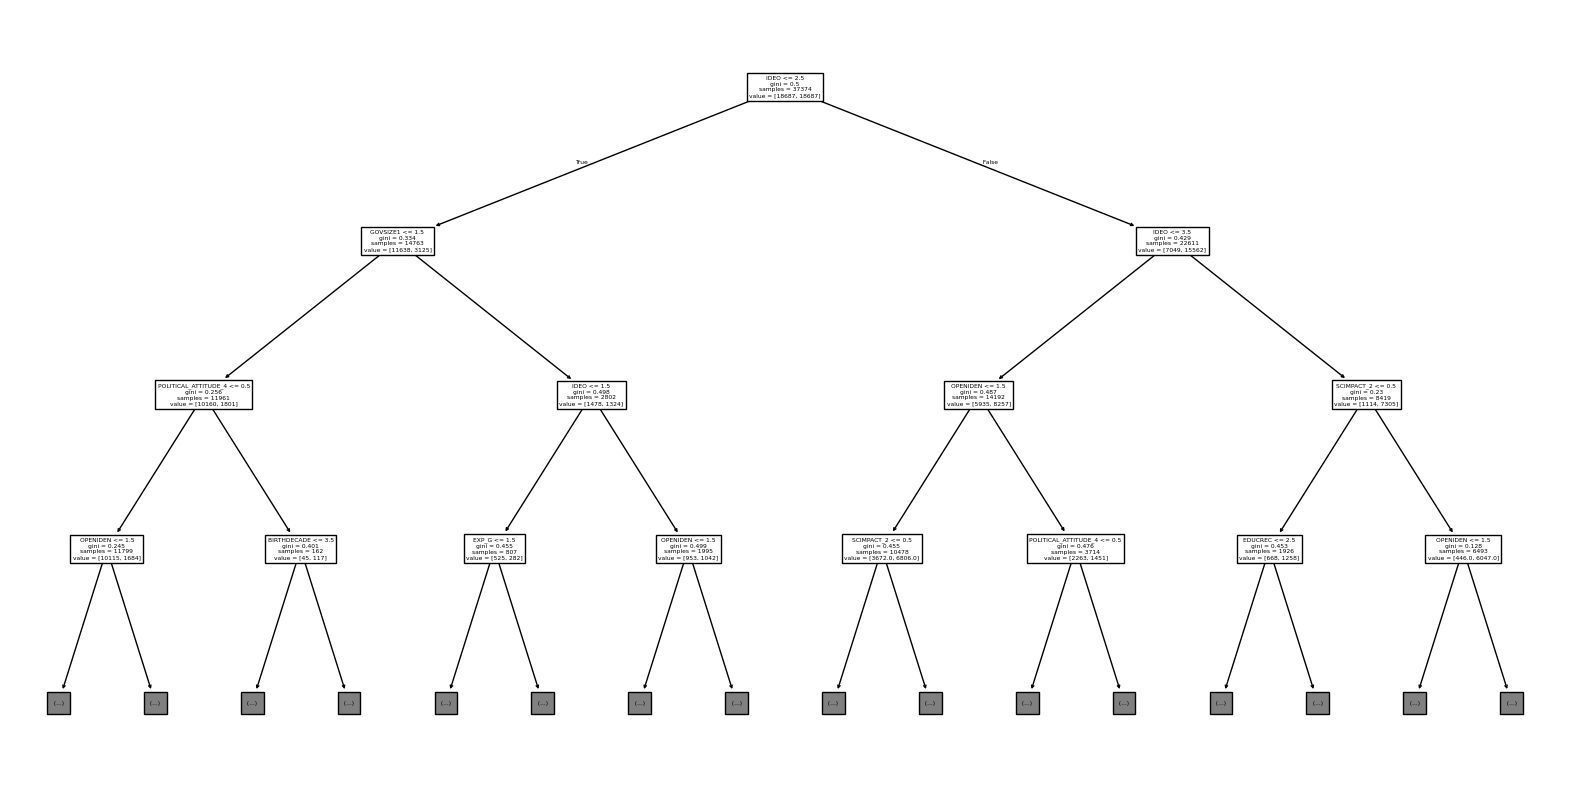

In [20]:
plt.figure(figsize=(20,10))
tree.plot_tree(dt,
               feature_names=X_train.columns,
               max_depth = 3)
plt.savefig('../results/03_dt_visualization.svg', bbox_inches='tight')
plt.show()

In [21]:
y_pred_dt = dt.predict(X_test)
# display(y_test)
# display(y_pred_dt)

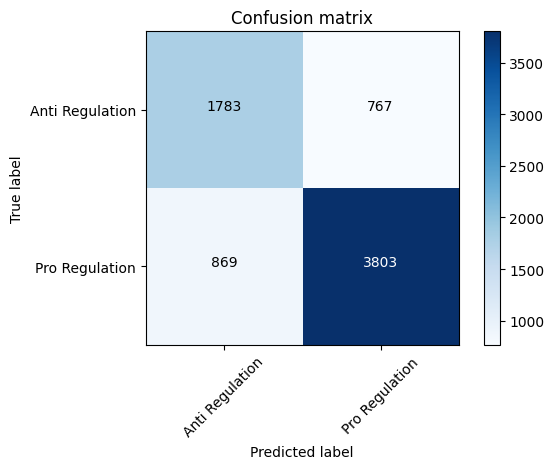

In [22]:
cnf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

np.set_printoptions(precision=2)
plot_confusion_matrix(cnf_matrix_dt, classes=['Anti Regulation', 'Pro Regulation'])
plt.savefig('../results/03_cnf_matrix_dt.svg', bbox_inches='tight')
plt.show()

In [23]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print('Model Accuracy:', accuracy_dt)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.7734699529216283

Classification Report:
                 precision    recall  f1-score   support

Anti Regulation       0.67      0.70      0.69      2550
 Pro Regulation       0.83      0.81      0.82      4672

       accuracy                           0.77      7222
      macro avg       0.75      0.76      0.75      7222
   weighted avg       0.78      0.77      0.77      7222



### 1.2 Logistic Classifier

#### 1.2.1 Default Model

In [24]:
lr_default = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_default.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [25]:
y_pred_lr_default = lr_default.predict(X_test_scaled)
# display(y_test)
# display(y_pred_lr_default)

In [26]:
accuracy_lr_default = accuracy_score(y_test, y_pred_lr_default)
print('Model Accuracy:', accuracy_lr_default)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr_default, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.795624480753254

Classification Report:
                 precision    recall  f1-score   support

Anti Regulation       0.67      0.83      0.74      2550
 Pro Regulation       0.89      0.78      0.83      4672

       accuracy                           0.80      7222
      macro avg       0.78      0.80      0.79      7222
   weighted avg       0.81      0.80      0.80      7222



#### 1.2.2 Hyperparameter Tuning

In [27]:
# estimator: Logistic Regression wrapped in ImbPipeline (with scaler)

lr_pipeline = ImbPipeline([
    ('oversampler', RandomOverSampler(random_state=68169)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

param_dist_lr = {
    'model__C': loguniform(1e-3, 1e2),
    'model__l1_ratio': uniform(0, 1)
}

# specify the cross validation
stratified_10_fold_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# create the search instance
random_search_lr = RandomizedSearchCV(
    estimator = lr_pipeline,
    param_distributions = param_dist_lr,
    n_iter = 100,
    scoring = 'f1_macro',
    cv = stratified_10_fold_cv,
    return_train_score = False,
    n_jobs = -1,
    random_state= RANDOM_STATE
)

# run the search on PRE-OVERSAMPLED data (Pipeline handles oversampling + scaling per fold)
random_search_lr.fit(X_train_orig, y_train_orig)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': <scipy.stats....x7fd240935010>, 'model__l1_ratio': <scipy.stats....x7fd240e48560>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` de

In [28]:
# report best score and parameters
print(f'Best CV Score (F1-Macro): {random_search_lr.best_score_:.4f}')
print(f'Best Hyperparameters: {random_search_lr.best_params_}')

# strip model__ prefix for use in final model
best_params_lr = {k.replace('model__', ''): v for k, v in random_search_lr.best_params_.items()}
print(f'Clean params for final model: {best_params_lr}')

# Evaluate best pipeline on test set
test_score_lr = random_search_lr.best_estimator_.score(X_test, y_test)
print(f"Test Set Score: {test_score_lr:.4f}")

Best CV Score (F1-Macro): 0.7737
Best Hyperparameters: {'model__C': np.float64(0.050737814374886406), 'model__l1_ratio': np.float64(0.11347352124058907)}
Clean params for final model: {'C': np.float64(0.050737814374886406), 'l1_ratio': np.float64(0.11347352124058907)}
Test Set Score: 0.7955


####  1.2.3 Final Model

In [29]:
lr = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    **best_params_lr,
    max_iter=5000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_scaled, y_train)
print(f"Final LR params: {best_params_lr}")

Final LR params: {'C': np.float64(0.050737814374886406), 'l1_ratio': np.float64(0.11347352124058907)}


In [30]:
y_pred_lr = lr.predict(X_test_scaled)
# display(y_test)
# display(y_pred_lr)

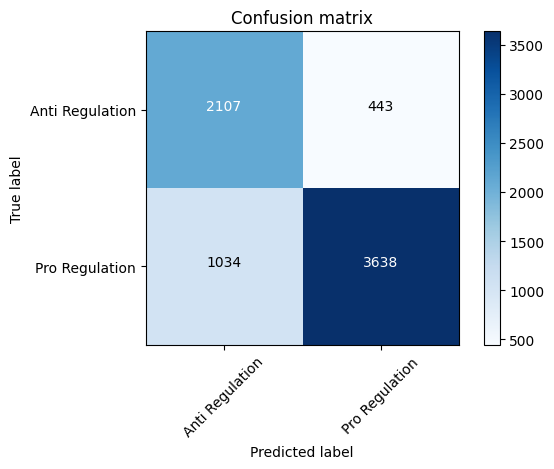

In [31]:
cnf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

np.set_printoptions(precision=2)
plot_confusion_matrix(cnf_matrix_lr, classes=['Anti Regulation', 'Pro Regulation'])
plt.savefig('../results/03_cnf_matrix_lr.svg', bbox_inches='tight')
plt.show()

In [32]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print('Model Accuracy:', accuracy_lr)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.7954860149543063

Classification Report:
                 precision    recall  f1-score   support

Anti Regulation       0.67      0.83      0.74      2550
 Pro Regulation       0.89      0.78      0.83      4672

       accuracy                           0.80      7222
      macro avg       0.78      0.80      0.79      7222
   weighted avg       0.81      0.80      0.80      7222



### 1.3 Random Forest

#### 1.3.1 Default Model

In [33]:
rf_default = RandomForestClassifier(random_state=RANDOM_STATE)
rf_default.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
y_pred_rf_default = rf_default.predict(X_test)
# display(y_test)
# display(y_pred_rf_default)

In [35]:
accuracy_rf_default = accuracy_score(y_test, y_pred_rf_default)
print('Model Accuracy:', accuracy_rf_default)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf_default, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.8003323179174744

Classification Report:
                 precision    recall  f1-score   support

Anti Regulation       0.72      0.71      0.71      2550
 Pro Regulation       0.84      0.85      0.85      4672

       accuracy                           0.80      7222
      macro avg       0.78      0.78      0.78      7222
   weighted avg       0.80      0.80      0.80      7222



#### 1.3.2 Hyperparameter Tuning

In [36]:
# estimator: Random Forest wrapped in ImbPipeline

rf_pipeline = ImbPipeline([
    ('oversampler', RandomOverSampler(random_state=68169)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

# specify the hyperparameter distribution
param_dist_rf = {
    'model__n_estimators' : [1, 10, 20, 30, 50, 100, 150],
    'model__max_depth': randint(1,30),
    'model__min_samples_leaf' : randint(1,20),
}

# specify the cross validation
stratified_10_fold_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# create the search instance
random_search_rf = RandomizedSearchCV(
    estimator = rf_pipeline, 
    param_distributions = param_dist_rf, 
    n_iter = 100,
    scoring = 'f1_macro', 
    cv = stratified_10_fold_cv, 
    return_train_score = False,
    random_state=RANDOM_STATE,
)

# run the search on PRE-OVERSAMPLED data
random_search_rf.fit(X_train_orig, y_train_orig)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': <scipy.stats....x7fd240947560>, 'model__min_samples_leaf': <scipy.stats....x7fd240b9af30>, 'model__n_estimators': [1, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies t

In [37]:
# report best score and parameters
print(f'Best CV Score (F1-Macro): {random_search_rf.best_score_:.4f}')
print(f'Best Hyperparameters: {random_search_rf.best_params_}')

# strip model__ prefix for use in final model
best_params_rf = {k.replace('model__', ''): v for k, v in random_search_rf.best_params_.items()}
print(f'Clean params for final model: {best_params_rf}')

# Evaluate best pipeline on test set
test_score_rf = random_search_rf.best_estimator_.score(X_test, y_test)
print(f"Test Set Score: {test_score_rf:.4f}")

Best CV Score (F1-Macro): 0.7779
Best Hyperparameters: {'model__max_depth': 26, 'model__min_samples_leaf': 3, 'model__n_estimators': 150}
Clean params for final model: {'max_depth': 26, 'min_samples_leaf': 3, 'n_estimators': 150}
Test Set Score: 0.8012


#### 1.3.3 Final Model
(based on hyperparameter tuning using either GridSearchCV or RandomizedSearchCV)

In [38]:
rf = RandomForestClassifier(
    **best_params_rf,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
print(f"Final RF params: {best_params_rf}")

Final RF params: {'max_depth': 26, 'min_samples_leaf': 3, 'n_estimators': 150}


In [39]:
y_pred_rf = rf.predict(X_test)
# display(y_test)
# display(y_pred_rf)

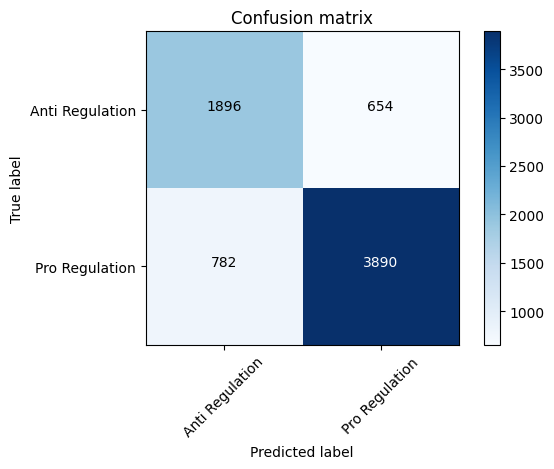

In [40]:
cnf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

np.set_printoptions(precision=2)
plot_confusion_matrix(cnf_matrix_rf, classes=['Anti Regulation', 'Pro Regulation'])
plt.savefig('../results/03_cnf_matrix_rf.svg', bbox_inches='tight')
plt.show()

In [41]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print('Model Accuracy:', accuracy_rf)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.8011631127111604

Classification Report:
                 precision    recall  f1-score   support

Anti Regulation       0.71      0.74      0.73      2550
 Pro Regulation       0.86      0.83      0.84      4672

       accuracy                           0.80      7222
      macro avg       0.78      0.79      0.78      7222
   weighted avg       0.80      0.80      0.80      7222



### 1.4 XGBoost

#### 1.4.1 Default Model

In [42]:
xg_default = XGBClassifier(random_state= RANDOM_STATE)
xg_default.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [43]:
y_pred_xg_default = xg_default.predict(X_test)
# display(y_test)
# display(y_pred_xg_default)

In [44]:
accuracy_xg_default = accuracy_score(y_test, y_pred_xg_default)
print('Model Accuracy:', accuracy_xg_default)

print('\nClassification Report')
print(classification_report(y_test, y_pred_xg_default, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.7899473829963999

Classification Report
                 precision    recall  f1-score   support

Anti Regulation       0.68      0.76      0.72      2550
 Pro Regulation       0.86      0.80      0.83      4672

       accuracy                           0.79      7222
      macro avg       0.77      0.78      0.78      7222
   weighted avg       0.80      0.79      0.79      7222



#### 1.4.2 Hyperparameter Tuning

In [45]:
# estimator: XGBoost wrapped in ImbPipeline

xg_pipeline = ImbPipeline([
    ('oversampler', RandomOverSampler(random_state=68169)),
    ('model', XGBClassifier(random_state=RANDOM_STATE, verbosity=0))
])

# specify the hyperparameter distribution
param_dist_xg = {
    'model__n_estimators' : [1, 10, 20, 30, 50, 100, 150],
    'model__max_depth': randint(1,30),
    'model__learning_rate': [0.05, 0.1, 0.5, 1],
}

# specify the cross validation
stratified_10_fold_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# create the search instance
random_search_xg = RandomizedSearchCV(
    estimator = xg_pipeline, 
    param_distributions = param_dist_xg, 
    n_iter = 100,
    scoring = 'f1_macro', 
    cv = stratified_10_fold_cv, 
    return_train_score = False,
    random_state=RANDOM_STATE,
)

# run the search on PRE-OVERSAMPLED data
random_search_xg.fit(X_train_orig, y_train_orig)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.05, 0.1, ...], 'model__max_depth': <scipy.stats....x7fd240cb60f0>, 'model__n_estimators': [1, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [46]:
# report best score and parameters
print(f'Best CV Score (F1-Macro): {random_search_xg.best_score_:.4f}')
print(f'Best Hyperparameters: {random_search_xg.best_params_}')

# strip model__ prefix for use in final model
best_params_xg = {k.replace('model__', ''): v for k, v in random_search_xg.best_params_.items()}
print(f'Clean params for final model: {best_params_xg}')

# Evaluate best pipeline on test set
test_score_xg = random_search_xg.best_estimator_.score(X_test, y_test)
print(f"Test Set Score: {test_score_xg:.4f}")

Best CV Score (F1-Macro): 0.7772
Best Hyperparameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 150}
Clean params for final model: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Test Set Score: 0.7967


#### 1.4.3 Final Model
(based on hyperparameter tuning using either GridSearchCV or RandomizedSearchCV)

In [47]:
xg = XGBClassifier(
    **best_params_xg,
    verbosity=0,
    random_state=RANDOM_STATE
)
xg.fit(X_train, y_train)
print(f"Final XGBoost params: {best_params_xg}")

Final XGBoost params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}


In [48]:
y_pred_xg = xg.predict(X_test)
# display(y_test)
# display(xg_prediction)

In [49]:
accuracy_xg = accuracy_score(y_test, y_pred_xg)
print('Model Accuracy:', accuracy_xg)

print('\nClassification Report')
print(classification_report(y_test, y_pred_xg, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.7967322071448353

Classification Report
                 precision    recall  f1-score   support

Anti Regulation       0.68      0.82      0.74      2550
 Pro Regulation       0.89      0.79      0.83      4672

       accuracy                           0.80      7222
      macro avg       0.78      0.80      0.79      7222
   weighted avg       0.81      0.80      0.80      7222



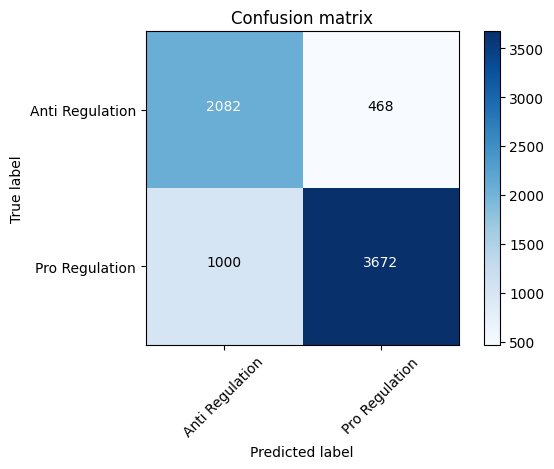

In [50]:
cnf_matrix_xg = confusion_matrix(y_test, y_pred_xg)

np.set_printoptions(precision=2)
plot_confusion_matrix(cnf_matrix_xg, classes=['Anti Regulation', 'Pro Regulation'])
plt.savefig('../results/03_cnf_matrix_xg.svg', bbox_inches='tight')
plt.show()

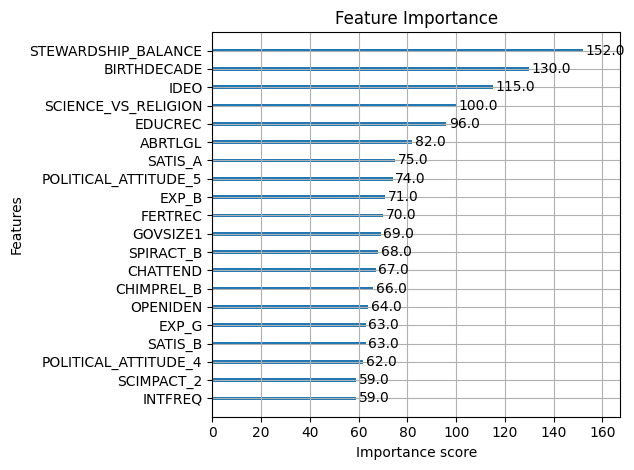

In [51]:
xgb.plot_importance(xg,max_num_features=20)
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig('../results/03_feat_importance_xg.svg', bbox_inches='tight')
plt.show()

### 1.5 Support-Vector-Machines (SVM)

#### 1.5.1 Default Model

In [52]:
svm_default = SVC(random_state=RANDOM_STATE)
svm_default.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [53]:
y_pred_svm_default = svm_default.predict(X_test_scaled)
# display(y_test)
# display(y_pred_svm_default)

In [54]:
accuracy_svm_default = accuracy_score(y_test, y_pred_svm_default)
print('Model Accuracy:', accuracy_svm_default)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm_default, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.794378288562725

Classification Report:
                 precision    recall  f1-score   support

Anti Regulation       0.68      0.80      0.73      2550
 Pro Regulation       0.88      0.79      0.83      4672

       accuracy                           0.79      7222
      macro avg       0.78      0.80      0.78      7222
   weighted avg       0.81      0.79      0.80      7222



#### 1.5.2 Hyperparameter Tuning

In [ ]:
# estimator: SVM wrapped in ImbPipeline (with scaler)

svm_pipeline = ImbPipeline([
    ('oversampler', RandomOverSampler(random_state=68169)),
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', random_state=RANDOM_STATE))
])

param_dist_svm = {
    'model__C': loguniform(1e-2, 1e2),
    'model__gamma': loguniform(1e-4, 1e0)
}

# specify the cross validation (10-fold
stratified_10_fold_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# create the search instance
random_search_svm = RandomizedSearchCV(
    estimator = svm_pipeline,
    param_distributions = param_dist_svm,
    n_iter = 10,
    scoring = 'f1_macro',
    cv = stratified_10_fold_cv,
    return_train_score = False,
    n_jobs = -1,
    random_state = RANDOM_STATE
)

# run the search on pre-oversampled data
random_search_svm.fit(X_train_orig, y_train_orig)

In [57]:
# report best score and parameters
print(f'Best CV Score (F1-Macro): {random_search_svm.best_score_:.4f}')
print(f'Best Hyperparameters: {random_search_svm.best_params_}')

# strip model__ prefix for use in final model
best_params_svm = {k.replace('model__', ''): v for k, v in random_search_svm.best_params_.items()}
print(f'Clean params for final model: {best_params_svm}')

# Evaluate best pipeline on test set
test_score_svm = random_search_svm.best_estimator_.score(X_test, y_test)
print(f"Test Set Score: {test_score_svm:.4f}")

Best CV Score (F1-Macro): 0.7741
Best Hyperparameters: {'model__C': np.float64(21.368329072358772), 'model__gamma': np.float64(0.0007068974950624604)}
Clean params for final model: {'C': np.float64(21.368329072358772), 'gamma': np.float64(0.0007068974950624604)}
Test Set Score: 0.7923


#### 1.5.3 Final Model

In [58]:
svm = SVC(
    kernel='rbf',
    **best_params_svm,
    probability=True,
    random_state=RANDOM_STATE
)
svm.fit(X_train_scaled, y_train)
print(f"Final SVM params: {best_params_svm}")

Final SVM params: {'C': np.float64(21.368329072358772), 'gamma': np.float64(0.0007068974950624604)}


In [59]:
y_pred_svm = svm.predict(X_test_scaled)
# display(y_test)
# display(y_pred_svm)

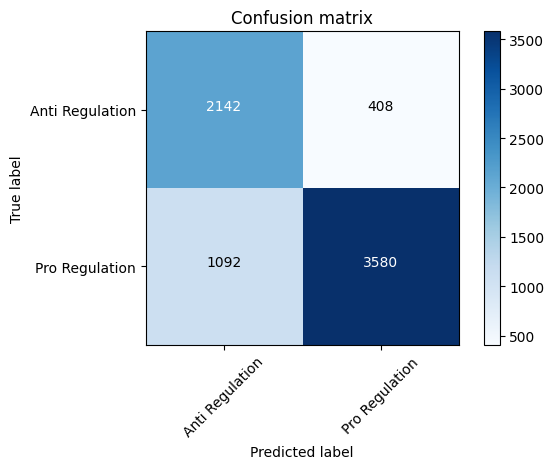

In [60]:
cnf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

np.set_printoptions(precision=2)
plot_confusion_matrix(cnf_matrix_svm, classes=['Anti Regulation', 'Pro Regulation'])
plt.savefig('../results/03_cnf_matrix_svm.svg', bbox_inches='tight')
plt.show()

In [61]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print('Model Accuracy:', accuracy_svm)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=['Anti Regulation', 'Pro Regulation']))

Model Accuracy: 0.7923013015785101

Classification Report:
                 precision    recall  f1-score   support

Anti Regulation       0.66      0.84      0.74      2550
 Pro Regulation       0.90      0.77      0.83      4672

       accuracy                           0.79      7222
      macro avg       0.78      0.80      0.78      7222
   weighted avg       0.81      0.79      0.80      7222



## Part 2: Evaluation Methods / Comparing Results

Planned evaluation:
- Accuracy, Precision, Recall, F1-Score (per class and macro/weighted)
- Confusion matrices
- ROC-AUC curves
- Feature importance comparison across models
- Cross-validation scores

### 2.0 Baseline (Majority-Class Classifier)
A `DummyClassifier(strategy='most_frequent')` predicts the majority class (pro-regulation) for every sample. This provides a floor: any useful model must beat it.

Baseline Accuracy (always predict majority class): 0.6469

Classification Report:
                 precision    recall  f1-score   support

Anti Regulation       0.00      0.00      0.00      2550
 Pro Regulation       0.65      1.00      0.79      4672

       accuracy                           0.65      7222
      macro avg       0.32      0.50      0.39      7222
   weighted avg       0.42      0.65      0.51      7222



e:\applications\Python\py3.12.8\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\applications\Python\py3.12.8\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\applications\Python\py3.12.8\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


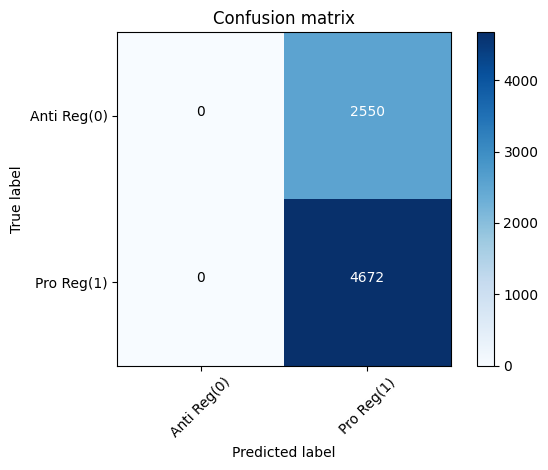

In [18]:
# ── 2.0 Baseline (Majority Class) ────────────────────────────────────────────
dummy = DummyClassifier(strategy='constant', constant = 1, random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
print(f"Baseline Accuracy (always predict majority class): {acc_dummy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dummy, target_names=['Anti Regulation', 'Pro Regulation']))

cnf_matrix_dummy = confusion_matrix(y_test, y_pred_dummy)

plot_confusion_matrix(
    cnf_matrix_dummy,
    classes=['Anti Reg(0)', 'Pro Reg(1)']
)


In [63]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Grouping our finalized models for easy iteration
models = {
    'Baseline (Majority)': dummy,
    'Decision Tree': dt,
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Support Vector Machine': svm,
    'XGBoost': xg
}

# Define target names for readability
target_names = ['Anti Regulation (0)', 'Pro Regulation (1)']

### 2.1 Accuracy, Precision, Recall, F1-Score (per class and marco/weight)

In tree model we use unscaled testset, while in LR and SVM we use scaled Xtest.
- Use current_X_test to represent whether scaled or not for specific model

In [64]:
# ── 2.1 Model Comparison Table ────────────────────────────────────────────────

results = []

for name, model in models.items():
    if name in ['Logistic Regression', 'Support Vector Machine']:
        current_X_test = X_test_scaled
    else:
        current_X_test = X_test
    
    # Get predictions and probabilities
    y_pred = model.predict(current_X_test)
    y_proba = model.predict_proba(current_X_test)[:, 1]
    
    # Calculate global metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Calculate class-specific and averaged metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'ROC-AUC': roc_auc,
        'F1 (Macro)': f1_macro,
        'Precision (Macro)': prec_macro,
        'Recall (Macro)': rec_macro,
        'F1 (Weighted)': f1_weighted,
        'Precision (Weighted)': prec_weighted,
        'Recall (Weighted)': rec_weighted,
        'Precision Class 0 (Anti)': precision[0],
        'Recall Class 0 (Anti)': recall[0],
        'F1 Class 0 (Anti)': f1[0],
        'Precision Class 1 (Pro)': precision[1],
        'Recall Class 1 (Pro)': recall[1],
        'F1 Class 1 (Pro)': f1[1]
    })

# Convert to DataFrame and sort by ROC-AUC
df_comparison = pd.DataFrame(results).sort_values(by='F1 (Macro)', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print("Model Performance Comparison (Sorted by F1-Macro):")
print(df_comparison)

/home/dino/LocalVenvs/jupytervenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dino/LocalVenvs/jupytervenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dino/LocalVenvs/jupytervenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

Model Performance Comparison (Sorted by F1-Macro):
                    Model  Accuracy   ROC-AUC  F1 (Macro)  Precision (Macro)  \
0                 XGBoost  0.796732  0.885337    0.786378           0.781246   
1     Logistic Regression  0.795486  0.879165    0.785863           0.781127   
2           Random Forest  0.801163  0.883690    0.784755           0.782032   
3  Support Vector Machine  0.792301  0.879529    0.783727           0.780015   
4           Decision Tree  0.773470  0.836810    0.754244           0.752245   
5     Baseline (Majority)  0.353088  0.500000    0.260950           0.176544   

   Recall (Macro)  F1 (Weighted)  Precision (Weighted)  Recall (Weighted)  \
0        0.801215       0.800197              0.812306           0.796732   
1        0.802478       0.799201              0.813542           0.795486   
2        0.788075       0.802216              0.803788           0.801163   
3        0.803134       0.796380              0.814592           0.792301   
4  

### 2.2 Confusion Matrix

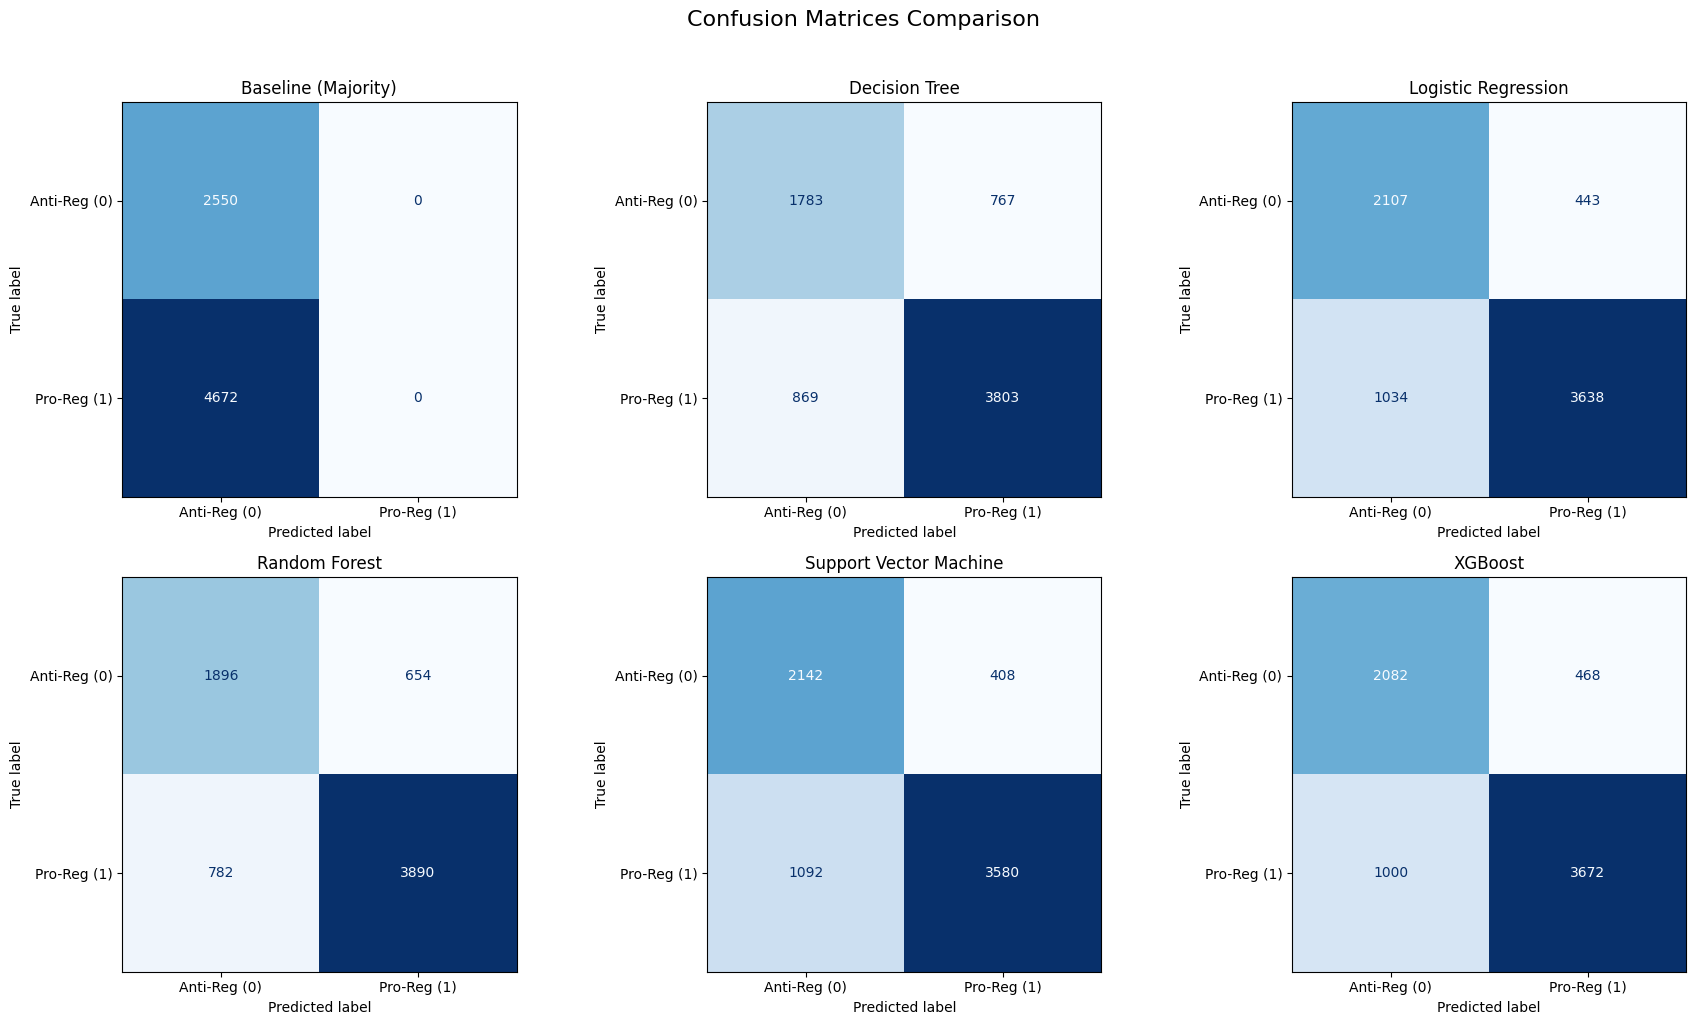

In [65]:
# ── 2.2 Confusion Matrices ────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('Confusion Matrices Comparison', fontsize=16, y=1.02)

for ax, (name, model) in zip(axes, models.items()):
    if name in ['Logistic Regression', 'Support Vector Machine']:
        current_X_test = X_test_scaled
    else:
        current_X_test = X_test
    y_pred = model.predict(current_X_test)
    
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, 
        display_labels=['Anti-Reg (0)', 'Pro-Reg (1)'],
        cmap=plt.cm.Blues, 
        ax=ax, 
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig('../results/03_evaluation_confusion_matrices.svg', bbox_inches='tight')
plt.show()

### 2.3 ROC-AUC Curves

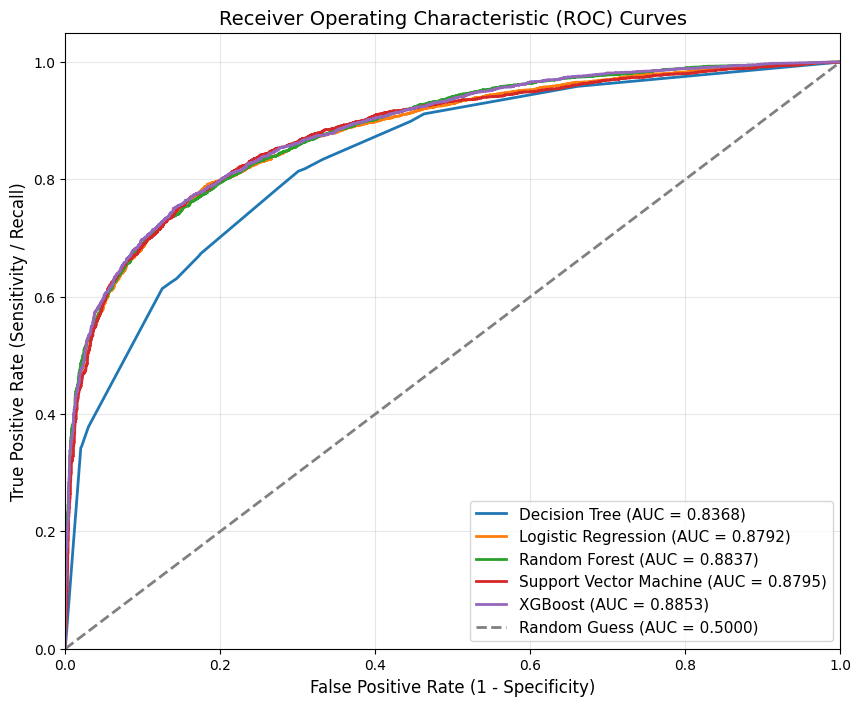

In [71]:
# ── 2.3 ROC-AUC Curves ────────────────────────────────────────────────────────

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if name == 'Baseline (Majority)':
        continue  # DummyClassifier ROC is trivial (AUC=0.5), skip for clarity
    if name in ['Logistic Regression', 'Support Vector Machine']:
        current_X_test = X_test_scaled
    else:
        current_X_test = X_test

    y_proba = model.predict_proba(current_X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.4f})')

# Plot the random guess baseline
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.savefig('../results/03_evaluation_roc_curves.svg', bbox_inches='tight')
plt.savefig('../results/03_evaluation_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.4 Feature Importance Comparison 

SVM with RBF kernel is difficult to extract feature importance, as all the features are mixed and mapped into high dimentional space. We can discuss whether we need it.

-For tree models (DT, RF, XGB), we use model.feature_importances_

-For logistic regression, we use abs(model.coef_[0])

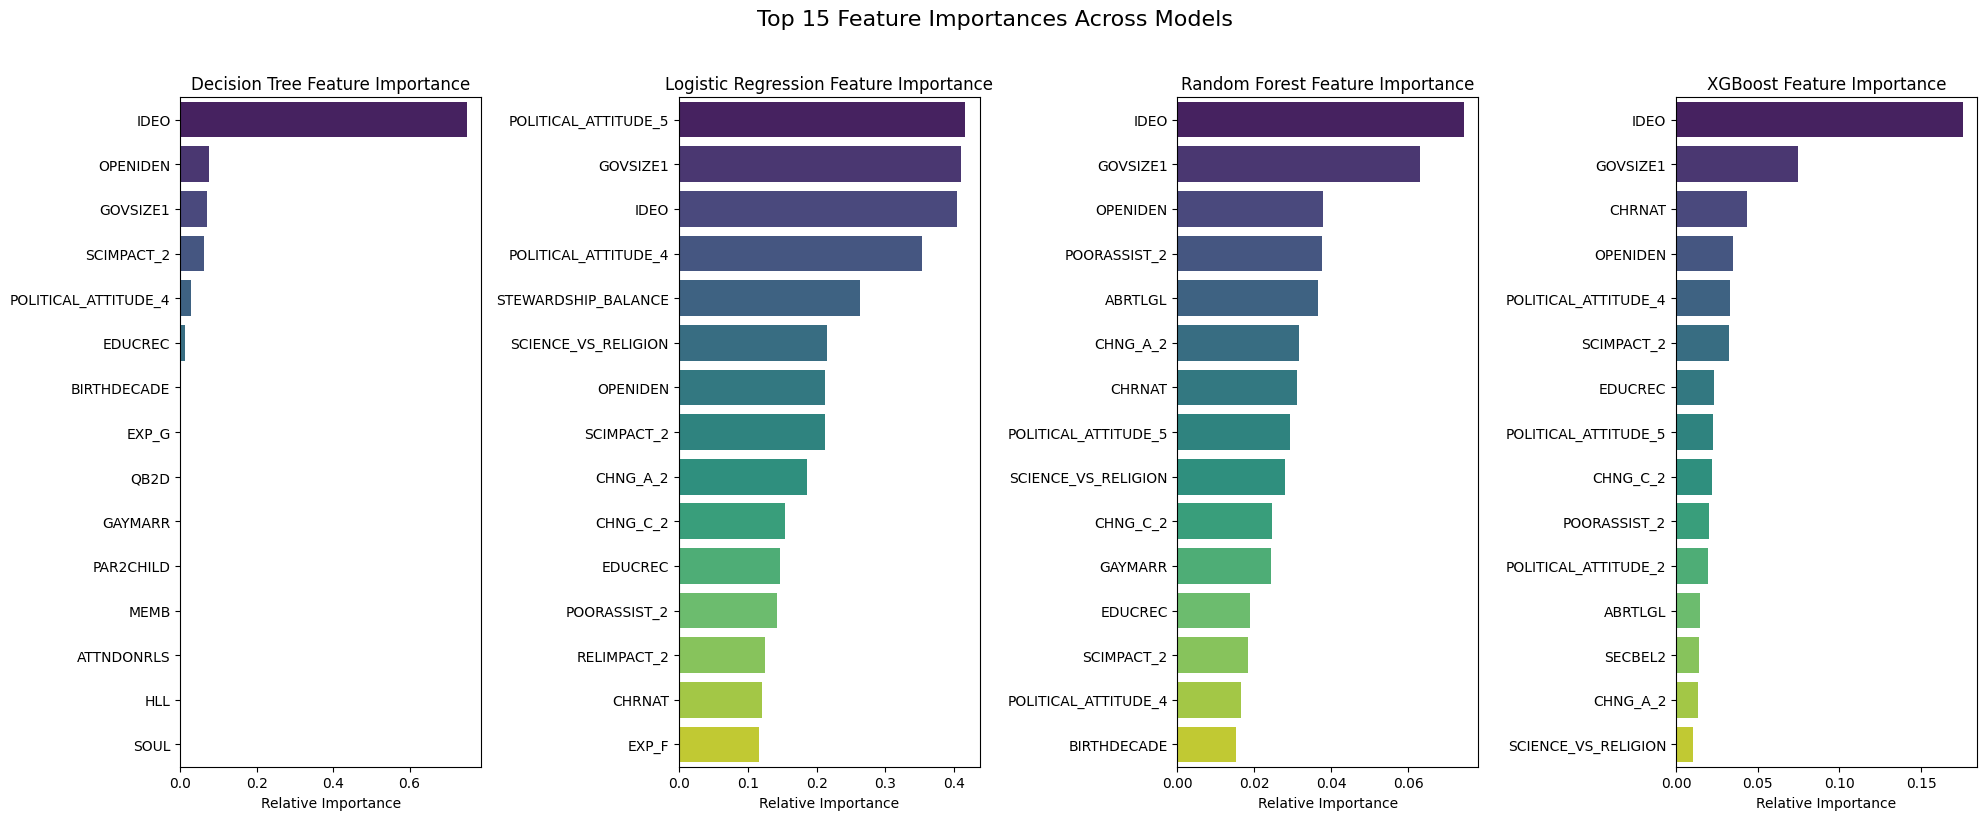

In [67]:
# Skip SVM (RBF kernel) and Baseline (no feature importance)
plot_model_names = ['Decision Tree', 'Logistic Regression', 'Random Forest', 'XGBoost']

fig, axes = plt.subplots(1, 4, figsize=(20, 8))
fig.suptitle('Top 15 Feature Importances Across Models', fontsize=16, y=1.02)

for i, name in enumerate(plot_model_names):

    ax = axes[i]
    model = models[name]
    # Extract importances
    if name == 'Logistic Regression':
        importances = np.abs(model.coef_[0])
    else:
        importances = model.feature_importances_
    
    # Create a DataFrame, sort it, and take the top 15
    feat_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(15)
    
    # Plot horizontal bar chart
    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=feat_df, 
        ax=ax, 
        palette='viridis',
        hue='Feature', 
        legend=False
    )
    
    ax.set_title(f'{name} Feature Importance')
    ax.set_xlabel('Relative Importance')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../results/03_evaluation_feature_importance.svg', bbox_inches='tight')
plt.show()

### 2.5 Cross Validation Scores

In [72]:
# ── 2.5 Cross-Validation  ─────────────────────────
# Oversampling happens inside each CV fold via ImbPipeline

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

cv_pipelines = {
    'Baseline (Majority)': ImbPipeline([
        ('oversampler', RandomOverSampler(random_state=68169)),
        ('model', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
    ]),
    'Decision Tree': ImbPipeline([
        ('oversampler', RandomOverSampler(random_state=68169)),
        ('model', DecisionTreeClassifier(**best_params_dt, random_state=RANDOM_STATE))
    ]),
    'Logistic Regression': ImbPipeline([
        ('oversampler', RandomOverSampler(random_state=68169)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(penalty='elasticnet', solver='saga',
                                     **best_params_lr, max_iter=5000,
                                     random_state=RANDOM_STATE))
    ]),
    'Random Forest': ImbPipeline([
        ('oversampler', RandomOverSampler(random_state=68169)),
        ('model', RandomForestClassifier(**best_params_rf, random_state=RANDOM_STATE))
    ]),
    'Support Vector Machine': ImbPipeline([
        ('oversampler', RandomOverSampler(random_state=68169)),
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', **best_params_svm, random_state=RANDOM_STATE))
    ]),
    'XGBoost': ImbPipeline([
        ('oversampler', RandomOverSampler(random_state=68169)),
        ('model', XGBClassifier(**best_params_xg, verbosity=0, random_state=RANDOM_STATE))
    ]),
}

for name, pipeline in cv_pipelines.items():
    scores = cross_val_score(pipeline, X_train_orig, y_train_orig,
                             cv=cv_strategy, scoring='f1_macro', n_jobs=1)
    
    cv_results.append({
        'Model': name,
        'Mean F1 (Macro)': scores.mean(),
        'Std Dev': scores.std(),
        'Min Score': scores.min(),
        'Max Score': scores.max()
    })

df_cv = pd.DataFrame(cv_results).sort_values(by='Mean F1 (Macro)', ascending=False).reset_index(drop=True)

print("10-Fold CV Stability Report (Pipeline-based, oversampling per fold):")
print(df_cv)

10-Fold CV Stability Report (Pipeline-based, oversampling per fold):
                    Model  Mean F1 (Macro)   Std Dev  Min Score  Max Score
0           Random Forest         0.777916  0.005201   0.771555   0.787604
1                 XGBoost         0.777217  0.005594   0.765694   0.786610
2  Support Vector Machine         0.774086  0.006369   0.761487   0.783372
3     Logistic Regression         0.773687  0.004212   0.765439   0.780618
4           Decision Tree         0.756869  0.008978   0.740411   0.768976
5     Baseline (Majority)         0.260969  0.000059   0.260936   0.261125
